In [2]:
#################################### Fig 4 ###########################################

#################################### RUE IS OPTIMIZED. Subfig 1 ###########################################
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns;sns.set_theme()
sns.set_color_codes()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp2d
import matplotlib.colors as colors

%matplotlib inline
sns.set_style('white')
sns.set_style("ticks")

Mounted at /content/drive


condition            : reference condition
genes in file        : 1625
matched to Table S6  : 1299 (79.9%)
dropped alpha > 5.0  : 1
genes plotted        : 1298
alpha new (s^-1)     : median 0.236  p5 0.073  p95 0.680
alpha old (s^-1)     : median 0.159  p5 0.044  p95 0.458
omega (s^-1)         : median 11.05  min 8.42  max 17.45
ABOVE LD-MC BOUNDARY : 2 / 1298 (0.15%)   <-- quote in response letter
 gene        a       w  exp_level
b4222 4.627330 9.39656      223.0
b1857 2.517042 9.49598      103.0


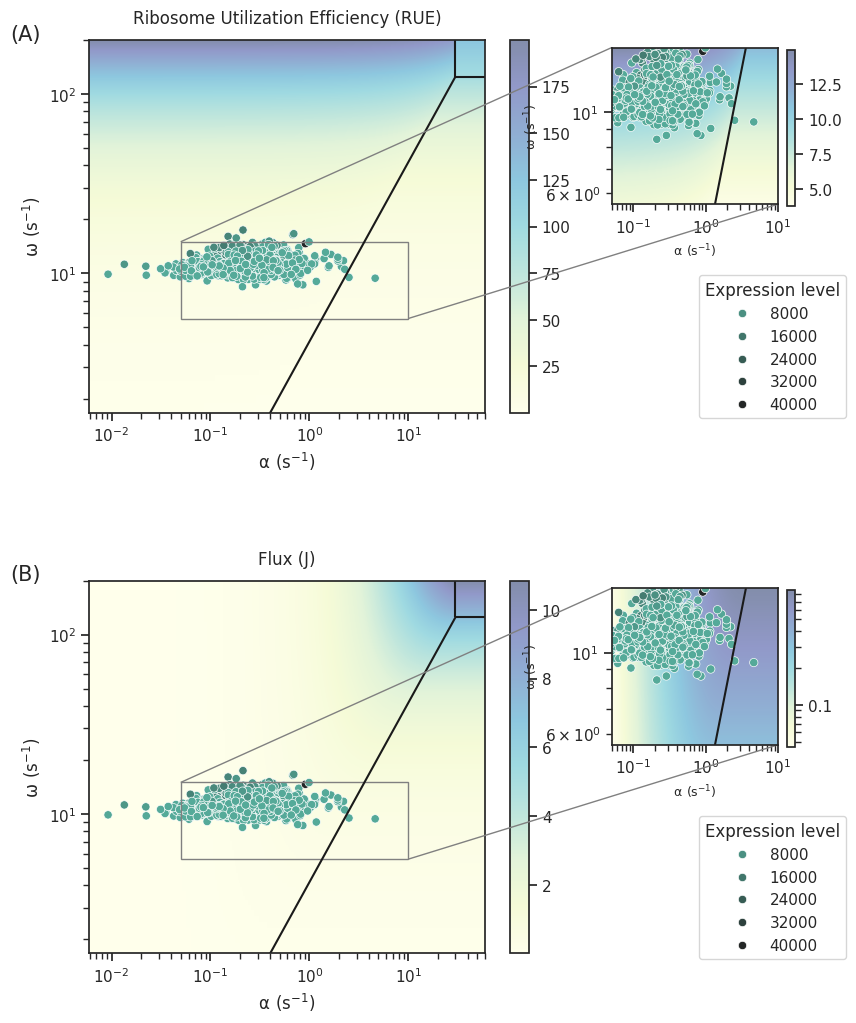

In [ ]:
# =============================================================================
# Figure 3 -- RUE and Flux on the alpha-omega TASEP phase diagram,
# with E. coli genes overlaid.
#
# Translation initiation rates (alpha) now come from
#   Balakrishnan et al., Science 2022, Table S6, "reference condition"
#   (E. coli K-12 NCM3722, glucose minimal medium, lambda = 0.91/h)
# replacing the previously used values, as requested by Referee 2.
#
# Elongation rates (w) and expression levels are unchanged, taken from
# te_ad_rue_exp_ir_w.txt.
#
# NOTE: the te / ad / rue columns of te_ad_rue_exp_ir_w.txt were computed with
# the OLD alpha. Fig. 3 does not plot them, but they are now stale. Set
# RECOMPUTE = True to refresh them from the analytical expressions (Table 1).
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

sns.set_theme()
sns.set_style('white')
sns.set_style('ticks')

BASE = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/'

# ------------------------------- settings ------------------------------------
CONDITION = 'reference condition'    # or 'C-limited condition'
ALPHA_CAP = 5.0                      # s^-1, drop non-physical outliers
RECOMPUTE = False                    # refresh te/ad/rue with the new alpha
L_FOOT    = 10                       # ribosome footprint, codons
BETA      = 30                       # termination rate, s^-1
# -----------------------------------------------------------------------------

# ========================= 1. new initiation rates ===========================
s6 = pd.read_excel(BASE + 'NIHMS1856867-supplement-Table_S6.xlsx',
                   sheet_name=CONDITION)
s6.columns = ['gene', 'locus', 'P_conc', 'mR_conc', 'G_conc',
              'alpha_p_min', 'delta_min', 'burstiness', 'alpha_m_min', 'k_on']
for col in ['alpha_p_min', 'alpha_m_min', 'delta_min', 'G_conc', 'mR_conc']:
    s6[col] = pd.to_numeric(s6[col], errors='coerce')

# Table S6 reports rates per MINUTE; the model works in per SECOND.
s6['a_new'] = s6['alpha_p_min'] / 60.0

s6_ok = s6.dropna(subset=['a_new'])
lookup = {}
for kcol in ['gene', 'locus']:
    lookup.update(dict(zip(s6_ok[kcol].astype(str).str.strip().str.lower(),
                           s6_ok['a_new'])))

# ========================= 2. your gene table ================================
df_wild = pd.read_csv(BASE + 'te_ad_rue_exp_ir_w.txt', sep=r'\s+')
df_wild.columns = ['g_no', 'gene', 'gene_name2', 'te', 'ad', 'rue',
                   'exp_level', 'a', 'w']
n_start = len(df_wild)

def match_alpha(row):
    for cand in (row['gene'], row['gene_name2']):
        k = str(cand).strip().lower()
        if k in lookup:
            return lookup[k]
    return np.nan

df_wild['a_old'] = df_wild['a']
df_wild['a'] = df_wild.apply(match_alpha, axis=1)

n_matched = int(df_wild['a'].notna().sum())
df_wild = df_wild.dropna(subset=['a', 'w'])
n_capped = int((df_wild['a'] > ALPHA_CAP).sum())
df_wild = df_wild[df_wild['a'] <= ALPHA_CAP].copy()

c_ld = 1 + np.sqrt(L_FOOT)
above = df_wild['a'] > df_wild['w'] / c_ld

print(f"condition            : {CONDITION}")
print(f"genes in file        : {n_start}")
print(f"matched to Table S6  : {n_matched} ({100*n_matched/n_start:.1f}%)")
print(f"dropped alpha > {ALPHA_CAP}  : {n_capped}")
print(f"genes plotted        : {len(df_wild)}")
print(f"alpha new (s^-1)     : median {df_wild['a'].median():.3f}  "
      f"p5 {df_wild['a'].quantile(.05):.3f}  p95 {df_wild['a'].quantile(.95):.3f}")
print(f"alpha old (s^-1)     : median {df_wild['a_old'].median():.3f}  "
      f"p5 {df_wild['a_old'].quantile(.05):.3f}  p95 {df_wild['a_old'].quantile(.95):.3f}")
print(f"omega (s^-1)         : median {df_wild['w'].median():.2f}  "
      f"min {df_wild['w'].min():.2f}  max {df_wild['w'].max():.2f}")
print(f"ABOVE LD-MC BOUNDARY : {int(above.sum())} / {len(df_wild)} "
      f"({100*above.mean():.2f}%)   <-- quote in response letter")
if above.sum():
    print(df_wild.loc[above, ['gene', 'a', 'w', 'exp_level']]
          .sort_values('a', ascending=False).to_string(index=False))

if RECOMPUTE:
    a_, w_ = df_wild['a'].values, df_wild['w'].values
    in_mc = a_ > w_ / c_ld
    r = a_ / w_
    te = np.where(in_mc, w_ / c_ld**2, a_ * (1 - r) / (1 + r * (L_FOOT - 1)))
    ad = np.where(in_mc, 1.0 / (np.sqrt(L_FOOT) * c_ld),
                  r / (1 + r * (L_FOOT - 1)))
    df_wild['te'], df_wild['ad'], df_wild['rue'] = te, ad, te / ad
    df_wild.to_csv(BASE + 'te_ad_rue_exp_ir_w_BALAKRISHNAN.txt',
                   sep='\t', index=False)
    print("recomputed te/ad/rue -> te_ad_rue_exp_ir_w_BALAKRISHNAN.txt")

# ========================= 3. heatmaps and grids =============================
rue_full   = pd.read_csv(BASE + 'rue_ana_heatmap1_aw_final_length_10.txt',
                         sep=',', header=None)
rue_subset = pd.read_csv(BASE + 'rue_ana_heatmap1_aw_final_subset_length_10.txt',
                         sep=',', header=None)
te_full    = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_length_10.txt',
                         sep=',', header=None)
te_subset  = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_subset_length_10.txt',
                         sep=',', header=None)

for d in (rue_full, rue_subset, te_full, te_subset):
    d[d <= 0] = np.nan

alpha_rates  = np.linspace(0.0, 60, 10000)
omega_rates  = np.linspace(0.0, 200, 1000)
alpha_rates1 = np.linspace(0.05, 10, 10000)
omega_rates1 = np.linspace(5, 15, 1000)

# ========================= 4. figure =========================================
fig, ax = plt.subplots(2, 1, figsize=(10, 10.5))

# --- FIX: extra vertical room so panel B's title clears panel A's x-label ---
fig.subplots_adjust(hspace=0.45, right=0.62, top=0.94, bottom=0.07)

for a_, l in zip(fig.get_axes(), ['(A)', '(B)']):
    a_.annotate(l, xy=(-0.2, 1.0), xycoords="axes fraction", fontsize=15)

beta = BETA
c = c_ld
x = np.linspace(0, beta, 20)
y = c * x

XLAB = r'$\mathrm{\alpha\hspace{.4}(s^{-1})}$'
YLAB = r'$\mathrm{\omega\hspace{.4}(s^{-1})}$'
inset_pos = [1.3, 0.4, 0.6, 0.6]

def draw_panel(axis, full, subset, title, subset_lognorm):
    axis.set_xscale("log")
    axis.set_yscale("log")
    im = axis.pcolormesh(alpha_rates, omega_rates, full,
                         cmap='YlGnBu', alpha=0.5)
    fig.colorbar(im, ax=axis)

    axis.plot(x, y, color="k", linewidth=1.5)
    axis.hlines(y=beta * c, xmin=beta, xmax=60, color="k", linewidth=1.5)
    axis.vlines(x=beta, ymin=beta * c, ymax=200, color="k", linewidth=1.5)

    sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                    palette="dark:#5A9_r", ax=axis)

    axis.set_xlabel(XLAB)
    axis.set_ylabel(YLAB)
    axis.set_title(title, pad=12)
    axis.legend(title="Expression level", loc="upper left",
                bbox_to_anchor=(1.52, 0.39))

    axi = inset_axes(axis, width="70%", height="70%", loc='upper left',
                     bbox_to_anchor=inset_pos, bbox_transform=axis.transAxes)
    kw = dict(cmap='YlGnBu', alpha=0.5)
    if subset_lognorm:
        kw['norm'] = LogNorm()
    axi.pcolormesh(alpha_rates1, omega_rates1, subset, **kw)

    cb = inset_axes(axi, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axi.transAxes)
    plt.colorbar(axi.collections[0], cax=cb, format="%.1f")

    sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                    palette='dark:#5A9_r', ax=axi, legend=False)

    axi.set_xlim(0.05, 10)
    axi.set_ylim(5.6, 15)
    axi.set_xscale("log")
    axi.set_yscale("log")
    axi.plot(x, y, color="k", linewidth=1.5)
    axi.hlines(y=beta * c, xmin=beta, xmax=10, color="k", linewidth=1.5)
    axi.vlines(x=beta, ymin=beta * c, ymax=15, color="k", linewidth=1.5)
    # --- FIX: proper LaTeX labels instead of seaborn's raw 'a' / 'w' ---
    axi.set_xlabel(XLAB, fontsize=9)
    axi.set_ylabel(YLAB, fontsize=9)
    mark_inset(axis, axi, loc1=2, loc2=4, fc="none", ec="0.5",
               edgecolor="black")
    return axi

draw_panel(ax[0], rue_full, rue_subset,
           'Ribosome Utilization Efficiency (RUE)', subset_lognorm=False)
draw_panel(ax[1], te_full, te_subset,
           'Flux (J)', subset_lognorm=True)

plt.savefig(BASE + 'Fig3_balakrishnan.png', dpi=600, bbox_inches='tight')
plt.savefig(BASE + 'Fig3_balakrishnan.pdf', bbox_inches='tight')
plt.show()

In [ ]:

# =============================================================================
# Figure 3 regenerated with translation initiation rates from
# Balakrishnan et al., Science 2022, Table S6 (reference condition).
#
# ONLY the initiation rate (column 'a') changes. Heatmaps, omega values,
# expression levels, phase boundaries, axes, colours and insets are identical
# to the original script.
#
# WARNING: the te / ad / rue columns in te_ad_rue_exp_ir_w.txt were computed
# with the OLD initiation rates. They are NOT used by this figure (Fig. 3 plots
# only a vs w, coloured by exp_level), but they are now stale -- do not reuse
# them anywhere else until recomputed. Set RECOMPUTE = True to refresh them.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

BASE = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/'

# ---- knobs -------------------------------------------------------------------
CONDITION  = 'reference condition'   # or 'C-limited condition'
ALPHA_CAP  = 5.0                     # s^-1; drop physically impossible outliers
RECOMPUTE  = False                   # recompute te/ad/rue from the new alpha
L_FOOT     = 10                      # ribosome footprint (codons)
BETA       = 30.0                    # termination rate (s^-1)
# ------------------------------------------------------------------------------

# =============================== NEW: load Table S6 ===========================
s6 = pd.read_excel(BASE + 'NIHMS1856867-supplement-Table_S6.xlsx',
                   sheet_name=CONDITION)
s6.columns = ['gene', 'locus', 'P_conc', 'mR_conc', 'G_conc',
              'alpha_p_min', 'delta_min', 'burstiness',
              'alpha_m_min', 'k_on']

for col in ['alpha_p_min', 'alpha_m_min', 'delta_min', 'G_conc', 'mR_conc']:
    s6[col] = pd.to_numeric(s6[col], errors='coerce')

# Table S6 rates are per MINUTE. The TASEP model works in per SECOND.
s6['a_new']       = s6['alpha_p_min']  / 60.0     # translation initiation, s^-1
s6['a_rnap_new']  = s6['alpha_m_min']  / 60.0     # transcription initiation, s^-1

s6['gene_key']  = s6['gene'].astype(str).str.strip().str.lower()
s6['locus_key'] = s6['locus'].astype(str).str.strip().str.lower()

# ============================== load your gene table ==========================
df_wild = pd.read_csv(BASE + 'te_ad_rue_exp_ir_w.txt', sep=r'\s+')
df_wild.columns = ['g_no', 'gene', 'gene_name2', 'te', 'ad', 'rue',
                   'exp_level', 'a', 'w']
n_start = len(df_wild)

# ============================== merge on gene / locus =========================
# Your identifiers may be gene names (thrA) or b-numbers (b0002); try both
# columns of your file against both identifier columns of Table S6.
lookup = {}
for kcol in ['gene_key', 'locus_key']:
    sub = s6.dropna(subset=['a_new'])
    lookup.update(dict(zip(sub[kcol], sub['a_new'])))

def match(row):
    for cand in [row['gene'], row['gene_name2']]:
        k = str(cand).strip().lower()
        if k in lookup:
            return lookup[k]
    return np.nan

df_wild['a_old'] = df_wild['a']
df_wild['a']     = df_wild.apply(match, axis=1)

n_matched = df_wild['a'].notna().sum()
df_wild = df_wild.dropna(subset=['a', 'w'])
n_capped = (df_wild['a'] > ALPHA_CAP).sum()
df_wild = df_wild[df_wild['a'] <= ALPHA_CAP]

print(f"condition        : {CONDITION}")
print(f"genes in file    : {n_start}")
print(f"matched to S6    : {n_matched}  ({100*n_matched/n_start:.1f}%)")
print(f"dropped a > {ALPHA_CAP} : {n_capped}")
print(f"genes plotted    : {len(df_wild)}")
print(f"alpha_new (s^-1) : median {df_wild['a'].median():.3f}  "
      f"p5 {df_wild['a'].quantile(.05):.3f}  p95 {df_wild['a'].quantile(.95):.3f}")
print(f"alpha_old (s^-1) : median {df_wild['a_old'].median():.3f}  "
      f"p5 {df_wild['a_old'].quantile(.05):.3f}  p95 {df_wild['a_old'].quantile(.95):.3f}")

# how many genes now sit above the LD-MC boundary alpha = w / (1 + sqrt(L))
c_ld = 1 + np.sqrt(L_FOOT)
above = df_wild['a'] > df_wild['w'] / c_ld
print(f"genes above LD-MC boundary: {above.sum()} / {len(df_wild)} "
      f"({100*above.mean():.2f}%)  <-- quote this number in the response letter")
if above.sum():
    print(df_wild.loc[above, ['gene', 'a', 'w', 'exp_level']]
          .sort_values('a', ascending=False).head(20).to_string(index=False))

# ---- optional: refresh te / ad / rue with the new alpha (LD + MC branches) ----
if RECOMPUTE:
    a, w = df_wild['a'].values, df_wild['w'].values
    in_mc = a > w / c_ld
    r = a / w
    te = np.where(in_mc, w / (1 + np.sqrt(L_FOOT))**2, a * (1 - r) / (1 + r*(L_FOOT-1)))
    ad = np.where(in_mc, 1/(np.sqrt(L_FOOT)*(1+np.sqrt(L_FOOT))), r / (1 + r*(L_FOOT-1)))
    df_wild['te'], df_wild['ad'], df_wild['rue'] = te, ad, te/ad
    df_wild.to_csv(BASE + 'te_ad_rue_exp_ir_w_BALAKRISHNAN.txt',
                   sep='\t', index=False)
    print("recomputed te/ad/rue written to te_ad_rue_exp_ir_w_BALAKRISHNAN.txt")

# =============================================================================
# EVERYTHING BELOW IS UNCHANGED FROM YOUR ORIGINAL SCRIPT
# =============================================================================

url1 = BASE + 'rue_ana_heatmap1_aw_final_length_10.txt'
df_heatmap = pd.read_csv(url1, sep=',', header=None)

url3 = BASE + 'rue_ana_heatmap1_aw_final_subset_length_10.txt'
df_subset_heatmap = pd.read_csv(url3, sep=',', header=None)

alpha_rates  = np.linspace(0.0, 60, 10000)
omega_rates  = np.linspace(0.0, 200, 1000)
alpha_rates1 = np.linspace(0.05, 10, 10000)
omega_rates1 = np.linspace(5, 15, 1000)

df_heatmap_logged = df_heatmap.copy()
df_subset_heatmap_logged = df_subset_heatmap.copy()
df_heatmap_logged[df_heatmap_logged <= 0] = np.nan
df_subset_heatmap_logged[df_subset_heatmap_logged <= 0] = np.nan

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharey=False)
texts = ['(A)', '(B)']
axes = fig.get_axes()
for a_, l in zip(axes, texts):
    a_.annotate(l, xy=(-0.2, 1.0), xycoords="axes fraction", fontsize=15)

beta = 30
c = (1 + np.sqrt(10))
x = np.linspace(0, beta, 20)
y = c * x

# ---- (A) RUE heatmap ----
ax[0].set_yscale("log"); ax[0].set_xscale("log")
im = ax[0].pcolormesh(alpha_rates, omega_rates, df_heatmap_logged,
                      cmap='YlGnBu', alpha=0.5)
fig.colorbar(im, ax=ax[0])
ax[0].plot(x, y, color="k", linewidth=1.5)
ax[0].hlines(y=beta*c, xmin=beta, xmax=60, color="k", linewidth=1.5)
ax[0].vlines(x=beta, ymin=beta*c, ymax=200, color="k", linewidth=1.5)
sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                palette="dark:#5A9_r", ax=ax[0])
ax[0].set_xlabel(r'$ \mathrm{\alpha\hspace{.4}(s^{-1})} $')
ax[0].set_ylabel(r'$ \mathrm{\omega\hspace{.4}(s^{-1})} $')
ax[0].set_title('Ribosome Utilization Efficiency (RUE)')
ax[0].legend(title="Expression level", loc="upper left",
             bbox_to_anchor=(1.52, 0.39))

inset_pos = [1.3, 0.4, 0.6, 0.6]
axins = inset_axes(ax[0], width="70%", height="70%", loc='upper left',
                   bbox_to_anchor=inset_pos, bbox_transform=ax[0].transAxes)
axins.pcolormesh(alpha_rates1, omega_rates1, df_subset_heatmap_logged,
                 cmap='YlGnBu', alpha=0.5)
cbaxes = inset_axes(axins, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axins.transAxes)
cbar = plt.colorbar(axins.collections[0], cax=cbaxes, format="%.1f")
sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                palette='dark:#5A9_r', ax=axins, legend=False)
x1, x2, y1, y2 = 0.05, 10, 5.6, 15
axins.set_xlim(x1, x2); axins.set_ylim(y1, y2)
axins.set_yscale("log"); axins.set_xscale("log")
axins.plot(x, y, color="k", linewidth=1.5)
axins.hlines(y=beta*c, xmin=beta, xmax=10, color="k", linewidth=1.5)
axins.vlines(x=beta, ymin=beta*c, ymax=15, color="k", linewidth=1.5)
mark_inset(ax[0], axins, loc1=2, loc2=4, fc="none", ec="0.5", edgecolor="black")

# ---- (B) Flux heatmap ----
df_heatmap = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_length_10.txt',
                         sep=',', header=None)
df_subset_heatmap = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_subset_length_10.txt',
                                sep=',', header=None)
df_heatmap_logged = df_heatmap.copy()
df_subset_heatmap_logged = df_subset_heatmap.copy()
df_heatmap_logged[df_heatmap_logged <= 0] = np.nan
df_subset_heatmap_logged[df_subset_heatmap_logged <= 0] = np.nan

ax[1].set_yscale("log"); ax[1].set_xscale("log")
im = ax[1].pcolormesh(alpha_rates, omega_rates, df_heatmap_logged,
                      cmap='YlGnBu', alpha=0.5)
fig.colorbar(im, ax=ax[1])
ax[1].plot(x, y, color="k", linewidth=1.5)
ax[1].hlines(y=beta*c, xmin=beta, xmax=60, color="k", linewidth=1.5)
ax[1].vlines(x=beta, ymin=beta*c, ymax=200, color="k", linewidth=1.5)
sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                palette="dark:#5A9_r", ax=ax[1])
ax[1].set_xlabel(r'$ \mathrm{\alpha\hspace{.4}(s^{-1})} $')
ax[1].set_ylabel(r'$ \mathrm{\omega\hspace{.4}(s^{-1})} $')
ax[1].set_title('Flux (J)')
ax[1].legend(title="Expression level", loc="upper left",
             bbox_to_anchor=(1.52, 0.39))

axins1 = inset_axes(ax[1], width="70%", height="70%", loc='upper left',
                    bbox_to_anchor=inset_pos, bbox_transform=ax[1].transAxes)
axins1.pcolormesh(alpha_rates1, omega_rates1, df_subset_heatmap_logged,
                  cmap='YlGnBu', alpha=0.5, norm=LogNorm())
cbaxes = inset_axes(axins1, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axins1.transAxes)
cbar = plt.colorbar(axins1.collections[0], cax=cbaxes, format="%.1f")
sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                palette='dark:#5A9_r', ax=axins1, legend=False)
axins1.set_xlim(x1, x2); axins1.set_ylim(y1, y2)
axins1.set_yscale("log"); axins1.set_xscale("log")
axins1.plot(x, y, color="k", linewidth=1.5)
axins1.hlines(y=beta*c, xmin=beta, xmax=10, color="k", linewidth=1.5)
axins1.vlines(x=beta, ymin=beta*c, ymax=15, color="k", linewidth=1.5)
mark_inset(ax[1], axins1, loc1=2, loc2=4, fc="none", ec="0.5", edgecolor="black")

plt.show()

condition        : reference condition
genes in file    : 1625
matched to S6    : 1299  (79.9%)
dropped a > 5.0 : 1
genes plotted    : 1298
alpha_new (s^-1) : median 0.236  p5 0.073  p95 0.680
alpha_old (s^-1) : median 0.159  p5 0.044  p95 0.458
genes above LD-MC boundary: 2 / 1298 (0.15%)  <-- quote this number in the response letter
 gene        a       w  exp_level
b4222 4.627330 9.39656      223.0
b1857 2.517042 9.49598      103.0


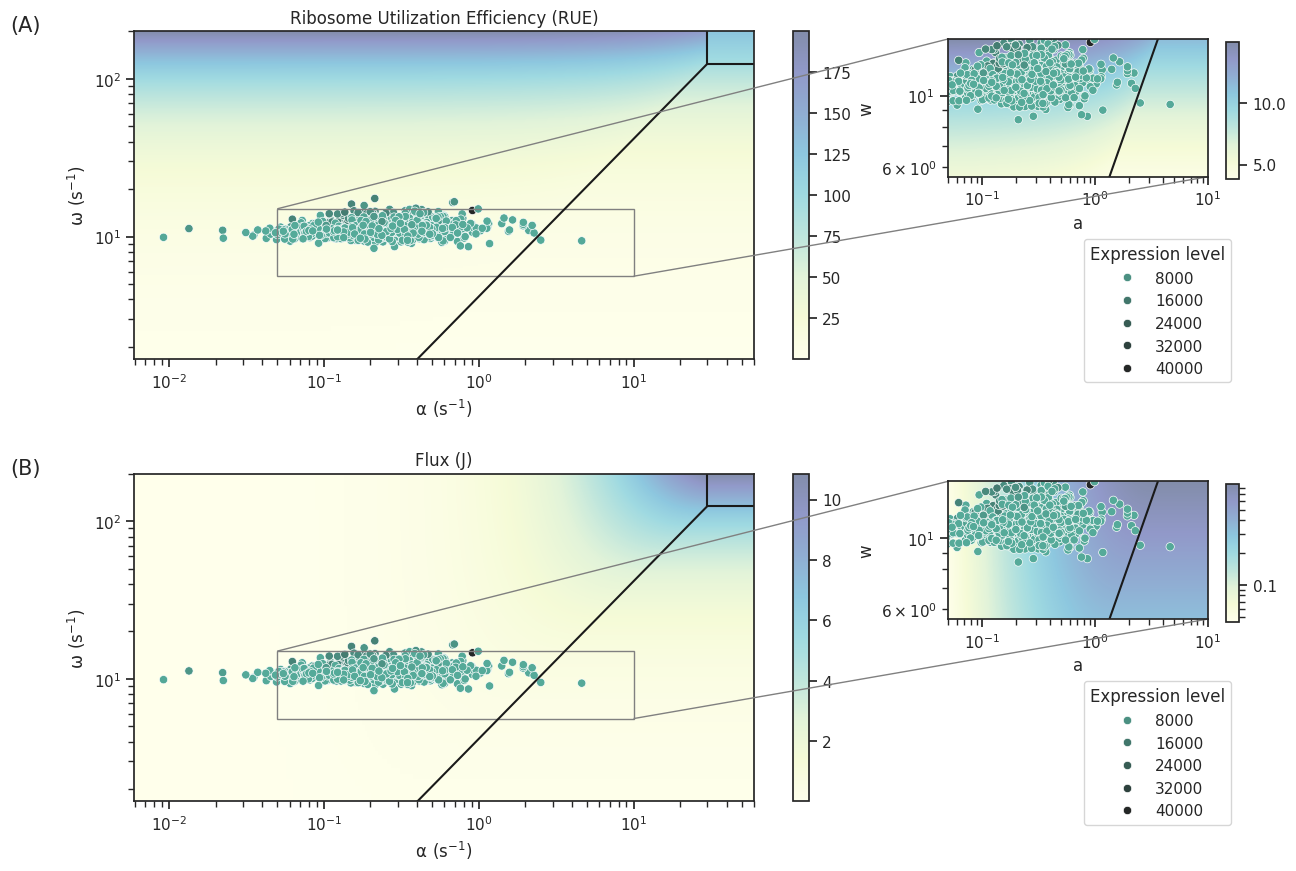

In [ ]:
# =============================================================================
# Figure 3 regenerated with translation initiation rates from
# Balakrishnan et al., Science 2022, Table S6 (reference condition).
#
# ONLY the initiation rate (column 'a') changes. Heatmaps, omega values,
# expression levels, phase boundaries, axes, colours and insets are identical
# to the original script.
#
# WARNING: the te / ad / rue columns in te_ad_rue_exp_ir_w.txt were computed
# with the OLD initiation rates. They are NOT used by this figure (Fig. 3 plots
# only a vs w, coloured by exp_level), but they are now stale -- do not reuse
# them anywhere else until recomputed. Set RECOMPUTE = True to refresh them.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

BASE = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/'

# ---- knobs -------------------------------------------------------------------
CONDITION  = 'reference condition'   # or 'C-limited condition'
ALPHA_CAP  = 5.0                     # s^-1; drop physically impossible outliers
RECOMPUTE  = False                   # recompute te/ad/rue from the new alpha
L_FOOT     = 10                      # ribosome footprint (codons)
BETA       = 30.0                    # termination rate (s^-1)
# ------------------------------------------------------------------------------

# =============================== NEW: load Table S6 ===========================
s6 = pd.read_excel(BASE + 'NIHMS1856867-supplement-Table_S6.xlsx',
                   sheet_name=CONDITION)
s6.columns = ['gene', 'locus', 'P_conc', 'mR_conc', 'G_conc',
              'alpha_p_min', 'delta_min', 'burstiness',
              'alpha_m_min', 'k_on']

for col in ['alpha_p_min', 'alpha_m_min', 'delta_min', 'G_conc', 'mR_conc']:
    s6[col] = pd.to_numeric(s6[col], errors='coerce')

# Table S6 rates are per MINUTE. The TASEP model works in per SECOND.
s6['a_new']       = s6['alpha_p_min']  / 60.0     # translation initiation, s^-1
s6['a_rnap_new']  = s6['alpha_m_min']  / 60.0     # transcription initiation, s^-1

s6['gene_key']  = s6['gene'].astype(str).str.strip().str.lower()
s6['locus_key'] = s6['locus'].astype(str).str.strip().str.lower()

# ============================== load your gene table ==========================
df_wild = pd.read_csv(BASE + 'te_ad_rue_exp_ir_w.txt', sep=r'\s+')
df_wild.columns = ['g_no', 'gene', 'gene_name2', 'te', 'ad', 'rue',
                   'exp_level', 'a', 'w']
n_start = len(df_wild)

# ============================== merge on gene / locus =========================
# Your identifiers may be gene names (thrA) or b-numbers (b0002); try both
# columns of your file against both identifier columns of Table S6.
lookup = {}
for kcol in ['gene_key', 'locus_key']:
    sub = s6.dropna(subset=['a_new'])
    lookup.update(dict(zip(sub[kcol], sub['a_new'])))

def match(row):
    for cand in [row['gene'], row['gene_name2']]:
        k = str(cand).strip().lower()
        if k in lookup:
            return lookup[k]
    return np.nan

df_wild['a_old'] = df_wild['a']
df_wild['a']     = df_wild.apply(match, axis=1)

n_matched = df_wild['a'].notna().sum()
df_wild = df_wild.dropna(subset=['a', 'w'])
n_capped = (df_wild['a'] > ALPHA_CAP).sum()
df_wild = df_wild[df_wild['a'] <= ALPHA_CAP]

print(f"condition        : {CONDITION}")
print(f"genes in file    : {n_start}")
print(f"matched to S6    : {n_matched}  ({100*n_matched/n_start:.1f}%)")
print(f"dropped a > {ALPHA_CAP} : {n_capped}")
print(f"genes plotted    : {len(df_wild)}")
print(f"alpha_new (s^-1) : median {df_wild['a'].median():.3f}  "
      f"p5 {df_wild['a'].quantile(.05):.3f}  p95 {df_wild['a'].quantile(.95):.3f}")
print(f"alpha_old (s^-1) : median {df_wild['a_old'].median():.3f}  "
      f"p5 {df_wild['a_old'].quantile(.05):.3f}  p95 {df_wild['a_old'].quantile(.95):.3f}")

# how many genes now sit above the LD-MC boundary alpha = w / (1 + sqrt(L))
c_ld = 1 + np.sqrt(L_FOOT)
above = df_wild['a'] > df_wild['w'] / c_ld
print(f"genes above LD-MC boundary: {above.sum()} / {len(df_wild)} "
      f"({100*above.mean():.2f}%)  <-- quote this number in the response letter")
if above.sum():
    print(df_wild.loc[above, ['gene', 'a', 'w', 'exp_level']]
          .sort_values('a', ascending=False).head(20).to_string(index=False))

# ---- optional: refresh te / ad / rue with the new alpha (LD + MC branches) ----
if RECOMPUTE:
    a, w = df_wild['a'].values, df_wild['w'].values
    in_mc = a > w / c_ld
    r = a / w
    te = np.where(in_mc, w / (1 + np.sqrt(L_FOOT))**2, a * (1 - r) / (1 + r*(L_FOOT-1)))
    ad = np.where(in_mc, 1/(np.sqrt(L_FOOT)*(1+np.sqrt(L_FOOT))), r / (1 + r*(L_FOOT-1)))
    df_wild['te'], df_wild['ad'], df_wild['rue'] = te, ad, te/ad
    df_wild.to_csv(BASE + 'te_ad_rue_exp_ir_w_BALAKRISHNAN.txt',
                   sep='\t', index=False)
    print("recomputed te/ad/rue written to te_ad_rue_exp_ir_w_BALAKRISHNAN.txt")

# =============================================================================
# EVERYTHING BELOW IS UNCHANGED FROM YOUR ORIGINAL SCRIPT
# =============================================================================

url1 = BASE + 'rue_ana_heatmap1_aw_final_length_10.txt'
df_heatmap = pd.read_csv(url1, sep=',', header=None)

url3 = BASE + 'rue_ana_heatmap1_aw_final_subset_length_10.txt'
df_subset_heatmap = pd.read_csv(url3, sep=',', header=None)

alpha_rates  = np.linspace(0.0, 60, 10000)
omega_rates  = np.linspace(0.0, 200, 1000)
alpha_rates1 = np.linspace(0.05, 10, 10000)
omega_rates1 = np.linspace(5, 15, 1000)

df_heatmap_logged = df_heatmap.copy()
df_subset_heatmap_logged = df_subset_heatmap.copy()
df_heatmap_logged[df_heatmap_logged <= 0] = np.nan
df_subset_heatmap_logged[df_subset_heatmap_logged <= 0] = np.nan

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharey=False)
fig.subplots_adjust(hspace=0.35)   # fix: prevent title / xlabel overlap
texts = ['(A)', '(B)']
axes = fig.get_axes()
for a_, l in zip(axes, texts):
    a_.annotate(l, xy=(-0.2, 1.0), xycoords="axes fraction", fontsize=15)

beta = 30
c = (1 + np.sqrt(10))
x = np.linspace(0, beta, 20)
y = c * x

# ---- (A) RUE heatmap ----
ax[0].set_yscale("log"); ax[0].set_xscale("log")
im = ax[0].pcolormesh(alpha_rates, omega_rates, df_heatmap_logged,
                      cmap='YlGnBu', alpha=0.5)
fig.colorbar(im, ax=ax[0])
ax[0].plot(x, y, color="k", linewidth=1.5)
ax[0].hlines(y=beta*c, xmin=beta, xmax=60, color="k", linewidth=1.5)
ax[0].vlines(x=beta, ymin=beta*c, ymax=200, color="k", linewidth=1.5)
sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                palette="dark:#5A9_r", ax=ax[0])
ax[0].set_xlabel(r'$ \mathrm{\alpha\hspace{.4}(s^{-1})} $')
ax[0].set_ylabel(r'$ \mathrm{\omega\hspace{.4}(s^{-1})} $')
ax[0].set_title('Ribosome Utilization Efficiency (RUE)')
ax[0].legend(title="Expression level", loc="upper left",
             bbox_to_anchor=(1.52, 0.39))

inset_pos = [1.3, 0.4, 0.6, 0.6]
axins = inset_axes(ax[0], width="70%", height="70%", loc='upper left',
                   bbox_to_anchor=inset_pos, bbox_transform=ax[0].transAxes)
axins.pcolormesh(alpha_rates1, omega_rates1, df_subset_heatmap_logged,
                 cmap='YlGnBu', alpha=0.5)
cbaxes = inset_axes(axins, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axins.transAxes)
cbar = plt.colorbar(axins.collections[0], cax=cbaxes, format="%.1f")
sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                palette='dark:#5A9_r', ax=axins, legend=False)
x1, x2, y1, y2 = 0.05, 10, 5.6, 15
axins.set_xlim(x1, x2); axins.set_ylim(y1, y2)
axins.set_yscale("log"); axins.set_xscale("log")
axins.plot(x, y, color="k", linewidth=1.5)
axins.hlines(y=beta*c, xmin=beta, xmax=10, color="k", linewidth=1.5)
axins.vlines(x=beta, ymin=beta*c, ymax=15, color="k", linewidth=1.5)
mark_inset(ax[0], axins, loc1=2, loc2=4, fc="none", ec="0.5", edgecolor="black")

# ---- (B) Flux heatmap ----
df_heatmap = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_length_10.txt',
                         sep=',', header=None)
df_subset_heatmap = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_subset_length_10.txt',
                                sep=',', header=None)
df_heatmap_logged = df_heatmap.copy()
df_subset_heatmap_logged = df_subset_heatmap.copy()
df_heatmap_logged[df_heatmap_logged <= 0] = np.nan
df_subset_heatmap_logged[df_subset_heatmap_logged <= 0] = np.nan

ax[1].set_yscale("log"); ax[1].set_xscale("log")
im = ax[1].pcolormesh(alpha_rates, omega_rates, df_heatmap_logged,
                      cmap='YlGnBu', alpha=0.5)
fig.colorbar(im, ax=ax[1])
ax[1].plot(x, y, color="k", linewidth=1.5)
ax[1].hlines(y=beta*c, xmin=beta, xmax=60, color="k", linewidth=1.5)
ax[1].vlines(x=beta, ymin=beta*c, ymax=200, color="k", linewidth=1.5)
sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                palette="dark:#5A9_r", ax=ax[1])
ax[1].set_xlabel(r'$ \mathrm{\alpha\hspace{.4}(s^{-1})} $')
ax[1].set_ylabel(r'$ \mathrm{\omega\hspace{.4}(s^{-1})} $')
ax[1].set_title('Flux (J)')
ax[1].legend(title="Expression level", loc="upper left",
             bbox_to_anchor=(1.52, 0.39))

axins1 = inset_axes(ax[1], width="70%", height="70%", loc='upper left',
                    bbox_to_anchor=inset_pos, bbox_transform=ax[1].transAxes)
axins1.pcolormesh(alpha_rates1, omega_rates1, df_subset_heatmap_logged,
                  cmap='YlGnBu', alpha=0.5, norm=LogNorm())
cbaxes = inset_axes(axins1, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axins1.transAxes)
cbar = plt.colorbar(axins1.collections[0], cax=cbaxes, format="%.1f")
sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                palette='dark:#5A9_r', ax=axins1, legend=False)
axins1.set_xlim(x1, x2); axins1.set_ylim(y1, y2)
axins1.set_yscale("log"); axins1.set_xscale("log")
axins1.plot(x, y, color="k", linewidth=1.5)
axins1.hlines(y=beta*c, xmin=beta, xmax=10, color="k", linewidth=1.5)
axins1.vlines(x=beta, ymin=beta*c, ymax=15, color="k", linewidth=1.5)
mark_inset(ax[1], axins1, loc1=2, loc2=4, fc="none", ec="0.5", edgecolor="black")

plt.show()

condition        : reference condition
genes in file    : 1625
matched to S6    : 1299  (79.9%)
dropped a > 5.0 : 1
genes plotted    : 1298
alpha_new (s^-1) : median 0.236  p5 0.073  p95 0.680
alpha_old (s^-1) : median 0.159  p5 0.044  p95 0.458
genes above LD-MC boundary: 2 / 1298 (0.15%)  <-- quote this number in the response letter
 gene        a       w  exp_level
b4222 4.627330 9.39656      223.0
b1857 2.517042 9.49598      103.0


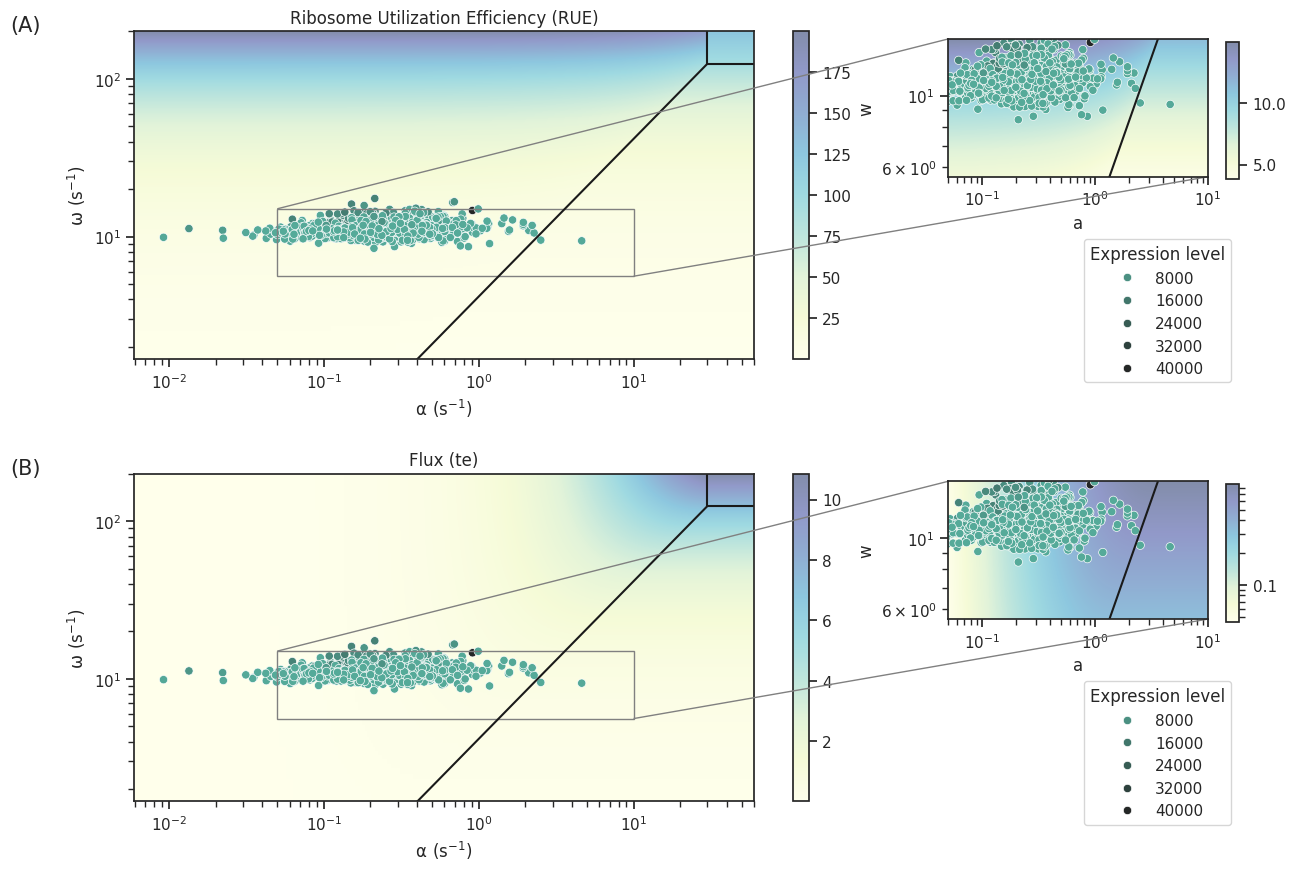

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# =============================================================================
# Figure 3 regenerated with translation initiation rates from
# Balakrishnan et al., Science 2022, Table S6 (reference condition).
#
# ONLY the initiation rate (column 'a') changes. Heatmaps, omega values,
# expression levels, phase boundaries, axes, colours and insets are identical
# to the original script.
#
# WARNING: the te / ad / rue columns in te_ad_rue_exp_ir_w.txt were computed
# with the OLD initiation rates. They are NOT used by this figure (Fig. 3 plots
# only a vs w, coloured by exp_level), but they are now stale -- do not reuse
# them anywhere else until recomputed. Set RECOMPUTE = True to refresh them.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

BASE = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/'

# ---- knobs -------------------------------------------------------------------
CONDITION  = 'reference condition'   # or 'C-limited condition'
ALPHA_CAP  = 5.0                     # s^-1; drop physically impossible outliers
RECOMPUTE  = False                   # recompute te/ad/rue from the new alpha
L_FOOT     = 10                      # ribosome footprint (codons)
BETA       = 30.0                    # termination rate (s^-1)
# ------------------------------------------------------------------------------

# =============================== NEW: load Table S6 ===========================
s6 = pd.read_excel(BASE + 'NIHMS1856867-supplement-Table_S6.xlsx',
                   sheet_name=CONDITION)
s6.columns = ['gene', 'locus', 'P_conc', 'mR_conc', 'G_conc',
              'alpha_p_min', 'delta_min', 'burstiness',
              'alpha_m_min', 'k_on']

for col in ['alpha_p_min', 'alpha_m_min', 'delta_min', 'G_conc', 'mR_conc']:
    s6[col] = pd.to_numeric(s6[col], errors='coerce')

# Table S6 rates are per MINUTE. The TASEP model works in per SECOND.
s6['a_new']       = s6['alpha_p_min']  / 60.0     # translation initiation, s^-1
s6['a_rnap_new']  = s6['alpha_m_min']  / 60.0     # transcription initiation, s^-1

s6['gene_key']  = s6['gene'].astype(str).str.strip().str.lower()
s6['locus_key'] = s6['locus'].astype(str).str.strip().str.lower()

# ============================== load your gene table ==========================
df_wild = pd.read_csv(BASE + 'te_ad_rue_exp_ir_w.txt', sep=r'\s+')
df_wild.columns = ['g_no', 'gene', 'gene_name2', 'te', 'ad', 'rue',
                   'exp_level', 'a', 'w']
n_start = len(df_wild)

# ============================== merge on gene / locus =========================
# Your identifiers may be gene names (thrA) or b-numbers (b0002); try both
# columns of your file against both identifier columns of Table S6.
lookup = {}
for kcol in ['gene_key', 'locus_key']:
    sub = s6.dropna(subset=['a_new'])
    lookup.update(dict(zip(sub[kcol], sub['a_new'])))

def match(row):
    for cand in [row['gene'], row['gene_name2']]:
        k = str(cand).strip().lower()
        if k in lookup:
            return lookup[k]
    return np.nan

df_wild['a_old'] = df_wild['a']
df_wild['a']     = df_wild.apply(match, axis=1)

n_matched = df_wild['a'].notna().sum()
df_wild = df_wild.dropna(subset=['a', 'w'])
n_capped = (df_wild['a'] > ALPHA_CAP).sum()
df_wild = df_wild[df_wild['a'] <= ALPHA_CAP]

print(f"condition        : {CONDITION}")
print(f"genes in file    : {n_start}")
print(f"matched to S6    : {n_matched}  ({100*n_matched/n_start:.1f}%)")
print(f"dropped a > {ALPHA_CAP} : {n_capped}")
print(f"genes plotted    : {len(df_wild)}")
print(f"alpha_new (s^-1) : median {df_wild['a'].median():.3f}  "
      f"p5 {df_wild['a'].quantile(.05):.3f}  p95 {df_wild['a'].quantile(.95):.3f}")
print(f"alpha_old (s^-1) : median {df_wild['a_old'].median():.3f}  "
      f"p5 {df_wild['a_old'].quantile(.05):.3f}  p95 {df_wild['a_old'].quantile(.95):.3f}")

# how many genes now sit above the LD-MC boundary alpha = w / (1 + sqrt(L))
c_ld = 1 + np.sqrt(L_FOOT)
above = df_wild['a'] > df_wild['w'] / c_ld
print(f"genes above LD-MC boundary: {above.sum()} / {len(df_wild)} "
      f"({100*above.mean():.2f}%)  <-- quote this number in the response letter")
if above.sum():
    print(df_wild.loc[above, ['gene', 'a', 'w', 'exp_level']]
          .sort_values('a', ascending=False).head(20).to_string(index=False))

# ---- optional: refresh te / ad / rue with the new alpha (LD + MC branches) ----
if RECOMPUTE:
    a, w = df_wild['a'].values, df_wild['w'].values
    in_mc = a > w / c_ld
    r = a / w
    te = np.where(in_mc, w / (1 + np.sqrt(L_FOOT))**2, a * (1 - r) / (1 + r*(L_FOOT-1)))
    ad = np.where(in_mc, 1/(np.sqrt(L_FOOT)*(1+np.sqrt(L_FOOT))), r / (1 + r*(L_FOOT-1)))
    df_wild['te'], df_wild['ad'], df_wild['rue'] = te, ad, te/ad
    df_wild.to_csv(BASE + 'te_ad_rue_exp_ir_w_BALAKRISHNAN.txt',
                   sep='\t', index=False)
    print("recomputed te/ad/rue written to te_ad_rue_exp_ir_w_BALAKRISHNAN.txt")

# =============================================================================
# EVERYTHING BELOW IS UNCHANGED FROM YOUR ORIGINAL SCRIPT
# =============================================================================

url1 = BASE + 'rue_ana_heatmap1_aw_final_length_10.txt'
df_heatmap = pd.read_csv(url1, sep=',', header=None)

url3 = BASE + 'rue_ana_heatmap1_aw_final_subset_length_10.txt'
df_subset_heatmap = pd.read_csv(url3, sep=',', header=None)

alpha_rates  = np.linspace(0.0, 60, 10000)
omega_rates  = np.linspace(0.0, 200, 1000)
alpha_rates1 = np.linspace(0.05, 10, 10000)
omega_rates1 = np.linspace(5, 15, 1000)

df_heatmap_logged = df_heatmap.copy()
df_subset_heatmap_logged = df_subset_heatmap.copy()
df_heatmap_logged[df_heatmap_logged <= 0] = np.nan
df_subset_heatmap_logged[df_subset_heatmap_logged <= 0] = np.nan

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharey=False)
fig.subplots_adjust(hspace=0.35)   # fix: prevent title / xlabel overlap
texts = ['(A)', '(B)']
axes = fig.get_axes()
for a_, l in zip(axes, texts):
    a_.annotate(l, xy=(-0.2, 1.0), xycoords="axes fraction", fontsize=15)

beta = 30
c = (1 + np.sqrt(10))
x = np.linspace(0, beta, 20)
y = c * x

# ---- (A) RUE heatmap ----
ax[0].set_yscale("log"); ax[0].set_xscale("log")
im = ax[0].pcolormesh(alpha_rates, omega_rates, df_heatmap_logged,
                      cmap='YlGnBu', alpha=0.5)
fig.colorbar(im, ax=ax[0])
ax[0].plot(x, y, color="k", linewidth=1.5)
ax[0].hlines(y=beta*c, xmin=beta, xmax=60, color="k", linewidth=1.5)
ax[0].vlines(x=beta, ymin=beta*c, ymax=200, color="k", linewidth=1.5)
sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                palette="dark:#5A9_r", ax=ax[0])
ax[0].set_xlabel(r'$ \mathrm{\alpha\hspace{.4}(s^{-1})} $')
ax[0].set_ylabel(r'$ \mathrm{\omega\hspace{.4}(s^{-1})} $')
ax[0].set_title('Ribosome Utilization Efficiency (RUE)')
ax[0].legend(title="Expression level", loc="upper left",
             bbox_to_anchor=(1.52, 0.39))

inset_pos = [1.3, 0.4, 0.6, 0.6]
axins = inset_axes(ax[0], width="70%", height="70%", loc='upper left',
                   bbox_to_anchor=inset_pos, bbox_transform=ax[0].transAxes)
axins.pcolormesh(alpha_rates1, omega_rates1, df_subset_heatmap_logged,
                 cmap='YlGnBu', alpha=0.5)
cbaxes = inset_axes(axins, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axins.transAxes)
cbar = plt.colorbar(axins.collections[0], cax=cbaxes, format="%.1f")
sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                palette='dark:#5A9_r', ax=axins, legend=False)
x1, x2, y1, y2 = 0.05, 10, 5.6, 15
axins.set_xlim(x1, x2); axins.set_ylim(y1, y2)
axins.set_yscale("log"); axins.set_xscale("log")
axins.plot(x, y, color="k", linewidth=1.5)
axins.hlines(y=beta*c, xmin=beta, xmax=10, color="k", linewidth=1.5)
axins.vlines(x=beta, ymin=beta*c, ymax=15, color="k", linewidth=1.5)
mark_inset(ax[0], axins, loc1=2, loc2=4, fc="none", ec="0.5", edgecolor="black")

# ---- (B) Flux heatmap ----
df_heatmap = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_length_10.txt',
                         sep=',', header=None)
df_subset_heatmap = pd.read_csv(BASE + 'te_ana_heatmap1_aw_final_subset_length_10.txt',
                                sep=',', header=None)
df_heatmap_logged = df_heatmap.copy()
df_subset_heatmap_logged = df_subset_heatmap.copy()
df_heatmap_logged[df_heatmap_logged <= 0] = np.nan
df_subset_heatmap_logged[df_subset_heatmap_logged <= 0] = np.nan

ax[1].set_yscale("log"); ax[1].set_xscale("log")
im = ax[1].pcolormesh(alpha_rates, omega_rates, df_heatmap_logged,
                      cmap='YlGnBu', alpha=0.5)
fig.colorbar(im, ax=ax[1])
ax[1].plot(x, y, color="k", linewidth=1.5)
ax[1].hlines(y=beta*c, xmin=beta, xmax=60, color="k", linewidth=1.5)
ax[1].vlines(x=beta, ymin=beta*c, ymax=200, color="k", linewidth=1.5)
sns.scatterplot(data=df_wild, x="a", y="w", hue="exp_level",
                palette="dark:#5A9_r", ax=ax[1])
ax[1].set_xlabel(r'$ \mathrm{\alpha\hspace{.4}(s^{-1})} $')
ax[1].set_ylabel(r'$ \mathrm{\omega\hspace{.4}(s^{-1})} $')
ax[1].set_title('Flux (te)')
ax[1].legend(title="Expression level", loc="upper left",
             bbox_to_anchor=(1.52, 0.39))

axins1 = inset_axes(ax[1], width="70%", height="70%", loc='upper left',
                    bbox_to_anchor=inset_pos, bbox_transform=ax[1].transAxes)
axins1.pcolormesh(alpha_rates1, omega_rates1, df_subset_heatmap_logged,
                  cmap='YlGnBu', alpha=0.5, norm=LogNorm())
cbaxes = inset_axes(axins1, width="5%", height="100%", loc='upper right',
                    bbox_to_anchor=(0.15, 0.036, 1, 1),
                    bbox_transform=axins1.transAxes)
cbar = plt.colorbar(axins1.collections[0], cax=cbaxes, format="%.1f")
sns.scatterplot(data=df_wild, x="a", y="w", hue='exp_level',
                palette='dark:#5A9_r', ax=axins1, legend=False)
axins1.set_xlim(x1, x2); axins1.set_ylim(y1, y2)
axins1.set_yscale("log"); axins1.set_xscale("log")
axins1.plot(x, y, color="k", linewidth=1.5)
axins1.hlines(y=beta*c, xmin=beta, xmax=10, color="k", linewidth=1.5)
axins1.vlines(x=beta, ymin=beta*c, ymax=15, color="k", linewidth=1.5)
mark_inset(ax[1], axins1, loc1=2, loc2=4, fc="none", ec="0.5", edgecolor="black")

plt.show()
fig.savefig("FIG_1_balakrishan.jpg", transparent=True, bbox_inches='tight', pad_inches=0,dpi=1000 )
from google.colab import files

files.download('/content/FIG_1_balakrishan.jpg')